In [1]:
!pip -q install kaggle

import os
import zipfile
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Setup complete.")

TensorFlow version: 2.19.0
Setup complete.


In [2]:
from google.colab import files
files.upload()  # upload kaggle.json here

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d jessicali9530/celeba-dataset

print("Download complete.")

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [01:33<00:00, 15.3MB/s]

Download complete.


Total images: 202599


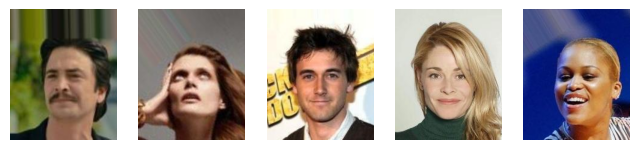

In [3]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import zipfile

# Unzip the dataset
zip_path = '/content/celeba-dataset.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

image_dir = "img_align_celeba/img_align_celeba"

#listing a few images
image_files = os.listdir(image_dir)
print("Total images:", len(image_files))

#showing some sample faces
plt.figure(figsize=(8,4))

for i in range(5):
    img_path = os.path.join(image_dir, image_files[i])
    img = Image.open(img_path)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [4]:
#image preprocessing pipeline
import tensorflow as tf

IMG_SIZE = 64
BATCH_SIZE = 128

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "img_align_celeba",
    labels=None,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Normalize pixels (0–255 → 0–1)
dataset = dataset.map(lambda x: x / 255.0)

print("Dataset ready.")

Found 202599 files.
Dataset ready.


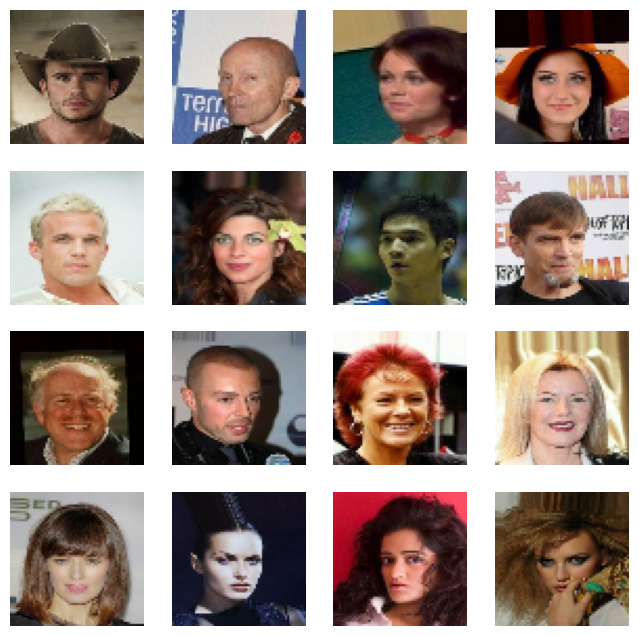

In [5]:
#visualizing a batch
import matplotlib.pyplot as plt

for batch in dataset.take(1):

    plt.figure(figsize=(8,8))

    for i in range(16):
        plt.subplot(4,4,i+1)
        plt.imshow(batch[i])
        plt.axis("off")

    plt.show()

In [6]:
#Building the VAE

LATENT_DIM = 128

encoder_inputs = keras.Input(shape=(64, 64, 3))

x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(encoder_inputs)
x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
x = layers.Conv2D(128, 3, strides=2, padding="same", activation="relu")(x)

x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)

z_mean = layers.Dense(LATENT_DIM, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM, name="z_log_var")(x)

encoder = keras.Model(encoder_inputs, [z_mean, z_log_var], name="encoder")

encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │     18,496 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 8, 8, 128) │     73,856 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8192)      │          0 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  2,097,408 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 128)       │     32,896 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 128)       │     32,896 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,256,448 (8.61 MB)

 Trainable params: 2,256,448 (8.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
#Sample layer
class Sampling(layers.Layer):

    def call(self, inputs):
        z_mean, z_log_var = inputs

        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]

        epsilon = tf.random.normal(shape=(batch, dim))

        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


# create sampled latent vector
z = Sampling()([z_mean, z_log_var])

print("Sampling layer created.")

Sampling layer created.


In [8]:
#Final encoder
encoder = keras.Model(
    encoder_inputs,
    [z_mean, z_log_var, z],
    name="encoder"
)

encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │     18,496 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 8, 8, 128) │     73,856 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8192)      │          0 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  2,097,408 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 128)       │     32,896 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 128)       │     32,896 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 128)       │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,256,448 (8.61 MB)

 Trainable params: 2,256,448 (8.61 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
#decoder
latent_inputs = keras.Input(shape=(LATENT_DIM,))

x = layers.Dense(8 * 8 * 128, activation="relu")(latent_inputs)
x = layers.Reshape((8, 8, 128))(x)

x = layers.Conv2DTranspose(128, 3, strides=2, padding="same", activation="relu")(x)
x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)

decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)

decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")

decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8192)           │     1,056,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 64, 64, 3)      │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,297,475 (4.95 MB)

 Trainable params: 1,297,475 (4.95 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
#building VAE
z_mean, z_log_var, z = encoder(encoder_inputs)
reconstructed = decoder(z)

vae = keras.Model(encoder_inputs, reconstructed, name="vae")

vae.summary()

Model: "vae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ [(None, 128), (None,   │     2,256,448 │
│                                 │ 128), (None, 128)]     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 64, 64, 3)      │     1,297,475 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,553,923 (13.56 MB)

 Trainable params: 3,553,923 (13.56 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
#VAE loss
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data, training=True)
            reconstruction = self.decoder(z, training=True)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2)
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            beta = 0.001  # start small
            total_loss = reconstruction_loss + beta * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "total_loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

vae = VAE(encoder, decoder)
print("Custom VAE class created.")

Custom VAE class created.


In [12]:
#Compile VAE
vae.compile(optimizer=keras.optimizers.Adam())

print("VAE compiled.")

VAE compiled.


In [13]:
#Training VAE
EPOCHS = 25

history = vae.fit(dataset, epochs=EPOCHS)

print("Training complete.")

Epoch 1/25
1583/1583 ━━━━━━━━━━━━━━━━━━━━ 94s 51ms/step - kl_loss: 528.8498 - reconstruction_loss: 2148.8201 - total_loss: 2149.3489
Epoch 2/25
1583/1583 ━━━━━━━━━━━━━━━━━━━━ 122s 45ms/step - kl_loss: 586.7814 - reconstruction_loss: 2053.5078 - total_loss: 2054.0935
Epoch 3/25
1583/1583 ━━━━━━━━━━━━━━━━━━━━ 70s 44ms/step - kl_loss: 590.3961 - reconstruction_loss: 2044.3678 - total_loss: 2044.9564
Epoch 4/25
1583/1583 ━━━━━━━━━━━━━━━━━━━━ 84s 45ms/step - kl_loss: 590.1995 - reconstruction_loss: 2039.8474 - total_loss: 2040.4349
Epoch 5/25
1583/1583 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - kl_loss: 586.3829 - reconstruction_loss: 2037.1217 - total_loss: 2037.7101
Epoch 6/25
1583/1583 ━━━━━━━━━━━━━━━━━━━━ 83s 45ms/step - kl_loss: 584.0081 - reconstruction_loss: 2035.5891 - total_loss: 2036.1709
Epoch 7/25
1583/1583 ━━━━━━━━━━━━━━━━━━━━ 70s 44ms/step - kl_loss: 582.9254 - reconstruction_loss: 2034.5049 - total_loss: 2035.0884
Epoch 8/25
1583/1583 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - kl_loss: 5

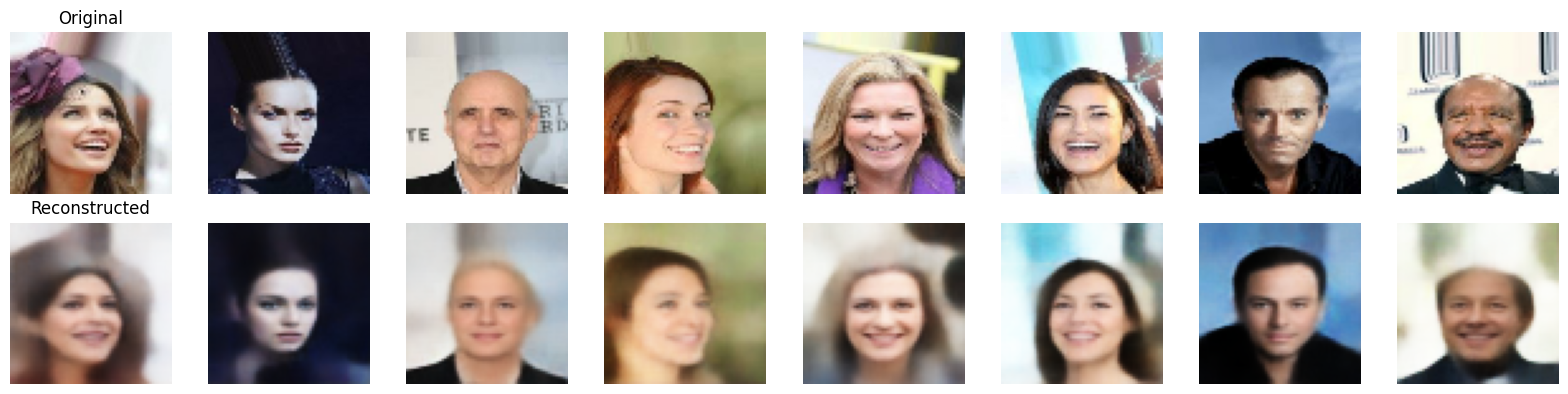

In [14]:
import matplotlib.pyplot as plt

for batch in dataset.take(1):
    originals = batch[:8]
    reconstructed = vae.decoder(vae.encoder(originals)[2])

    plt.figure(figsize=(16, 4))

    # Top row: originals
    for i in range(8):
        plt.subplot(2, 8, i + 1)
        plt.imshow(originals[i].numpy())
        plt.axis("off")
        if i == 0:
            plt.title("Original")

    # Bottom row: reconstructions
    for i in range(8):
        plt.subplot(2, 8, 8 + i + 1)
        plt.imshow(reconstructed[i].numpy())
        plt.axis("off")
        if i == 0:
            plt.title("Reconstructed")

    plt.tight_layout()
    plt.show()

In [15]:
#loading attribute table
attr_df = pd.read_csv("list_attr_celeba.csv")

print(attr_df.shape)
print(attr_df.columns[:10])
print(attr_df.head())

(202599, 41)
Index(['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive',
       'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose',
       'Black_Hair'],
      dtype='object')
     image_id  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  \
0  000001.jpg                -1                1           1               -1   
1  000002.jpg                -1               -1          -1                1   
2  000003.jpg                -1               -1          -1               -1   
3  000004.jpg                -1               -1           1               -1   
4  000005.jpg                -1                1           1               -1   

   Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  ...  Sideburns  Smiling  \
0    -1     -1        -1        -1          -1  ...         -1        1   
1    -1     -1        -1         1          -1  ...         -1        1   
2    -1     -1         1        -1          -1  ...         -1       -1   
3    -1     -1   

In [16]:
#attributes
target_attrs = ["Male", "Smiling", "Eyeglasses", "Black_Hair", "Blond_Hair"]

for col in target_attrs:
    print(col, "->", col in attr_df.columns)

Male -> True
Smiling -> True
Eyeglasses -> True
Black_Hair -> True
Blond_Hair -> True


In [18]:
#collecting latent vectors and attributes
import numpy as np

latent_vectors = []
attributes = []

max_batches = 100  # ~100 * 128 ≈ 12,800 images

for i, batch in enumerate(dataset.take(max_batches)):
    z_mean, _, _ = vae.encoder(batch, training=False)
    latent_vectors.append(z_mean.numpy())

# stack into one big array
latent_vectors = np.concatenate(latent_vectors, axis=0)

print("Latent shape:", latent_vectors.shape)

attr_subset = attr_df.iloc[:len(latent_vectors)]

print("Attr shape:", attr_subset.shape)

Latent shape: (12800, 128)
Attr shape: (12800, 41)


In [19]:
#attribute directions
def compute_direction(attr_name):
    pos_idx = attr_subset[attr_name] == 1
    neg_idx = attr_subset[attr_name] == -1

    z_pos = latent_vectors[pos_idx]
    z_neg = latent_vectors[neg_idx]

    direction = z_pos.mean(axis=0) - z_neg.mean(axis=0)
    return direction

# directions
male_dir = compute_direction("Male")
smile_dir = compute_direction("Smiling")
glasses_dir = compute_direction("Eyeglasses")

# hair: blonde vs black
blonde_idx = attr_subset["Blond_Hair"] == 1
black_idx = attr_subset["Black_Hair"] == 1

hair_dir = (
    latent_vectors[blonde_idx].mean(axis=0)
    - latent_vectors[black_idx].mean(axis=0)
)

print("Directions computed.")

Directions computed.


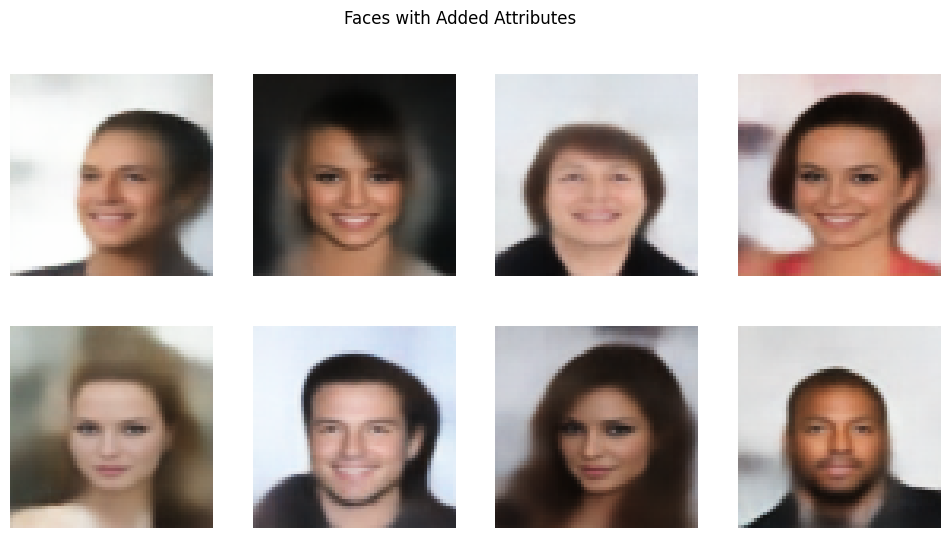

In [25]:
#applying latent arithmetic
import matplotlib.pyplot as plt

# sample random latent vectors
z_random = latent_vectors[:8]
# apply attributes
z_modified = (
    z_random
    + 2 * male_dir
    + 2 * smile_dir
    + 2 * glasses_dir
    + 2 * hair_dir
)

# decode
generated = vae.decoder(z_modified)

# show results
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(generated[i])
    plt.axis("off")

plt.suptitle("Faces with Added Attributes")
plt.show()

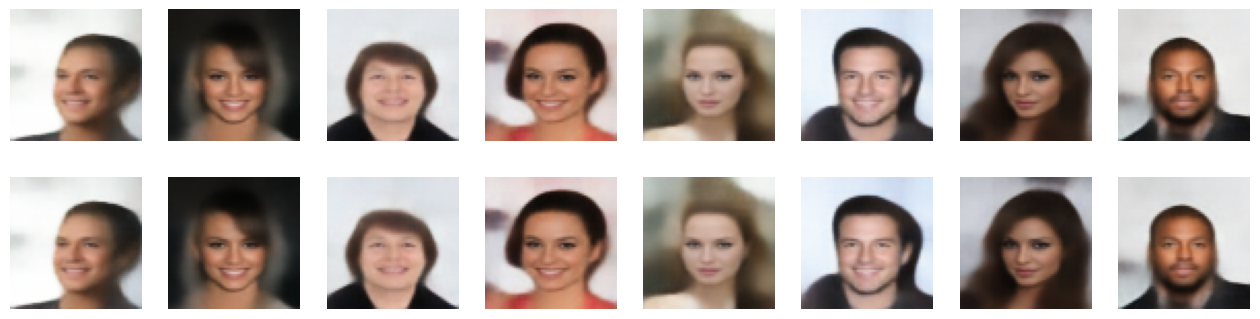

In [26]:
original = vae.decoder(z_random)
modified = vae.decoder(z_modified)

plt.figure(figsize=(16,4))

for i in range(8):
    plt.subplot(2,8,i+1)
    plt.imshow(original[i])
    plt.axis("off")

    plt.subplot(2,8,8+i+1)
    plt.imshow(modified[i])
    plt.axis("off")

plt.show()

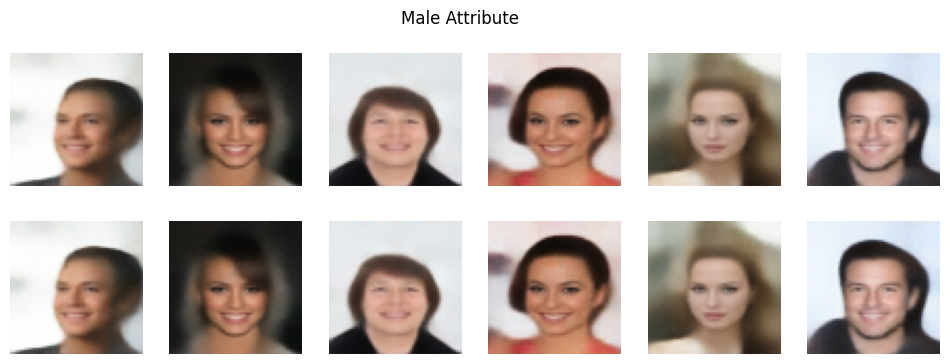

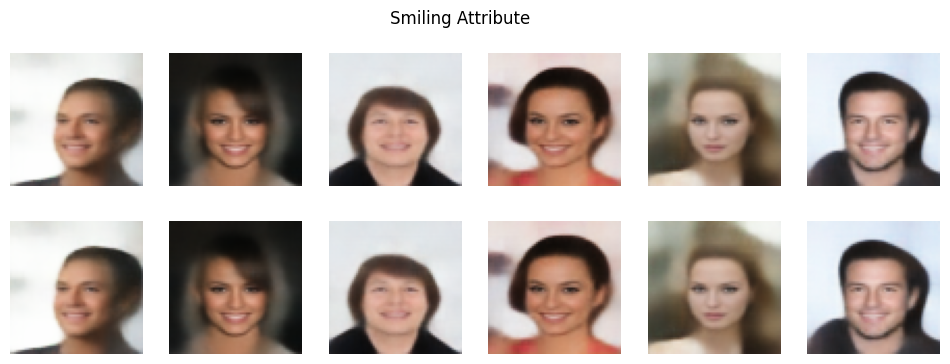

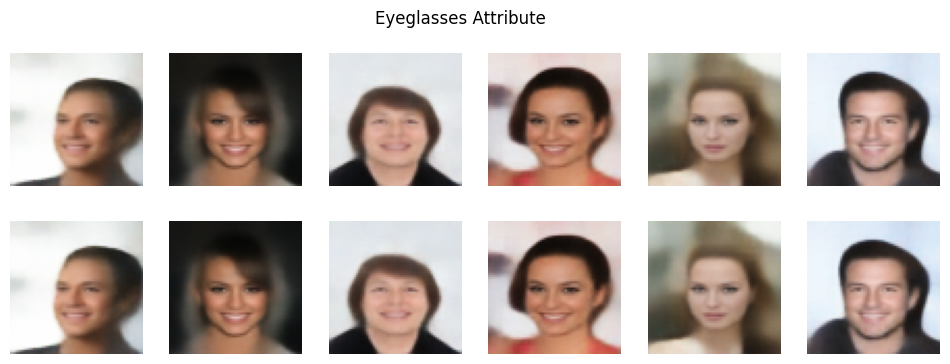

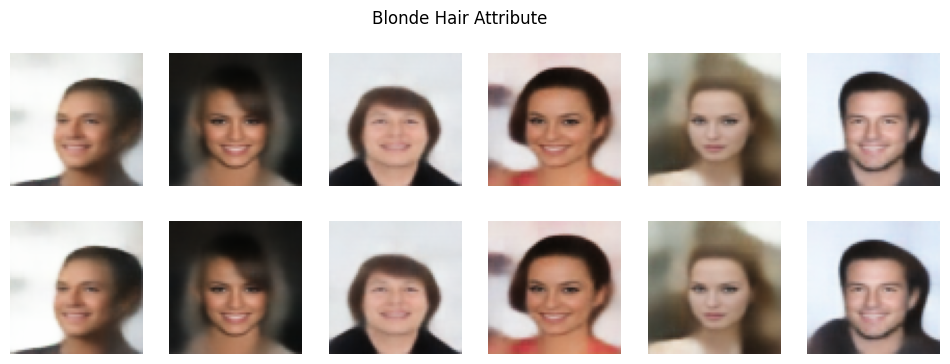

In [27]:
import matplotlib.pyplot as plt

z_base = latent_vectors[:6]  # keep same faces

strength = 1.5  # stronger but still safe

def show_edit(direction, title):
    z_modified = z_base + strength * direction

    original = vae.decoder(z_base)
    modified = vae.decoder(z_modified)

    plt.figure(figsize=(12,4))
    plt.suptitle(title)

    for i in range(6):
        # original
        plt.subplot(2,6,i+1)
        plt.imshow(original[i])
        plt.axis("off")

        # modified
        plt.subplot(2,6,6+i+1)
        plt.imshow(modified[i])
        plt.axis("off")

    plt.show()


# Apply each attribute separately
show_edit(male_dir, "Male Attribute")
show_edit(smile_dir, "Smiling Attribute")
show_edit(glasses_dir, "Eyeglasses Attribute")
show_edit(hair_dir, "Blonde Hair Attribute")

In [28]:
ordered_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "img_align_celeba",
    labels=None,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

ordered_dataset = ordered_dataset.map(lambda x: x / 255.0)

print("Ordered dataset ready.")

Found 202599 files.
Ordered dataset ready.


In [29]:
aligned_latent_vectors = []

max_batches = 100  # same subset size as before

for batch in ordered_dataset.take(max_batches):
    z_mean, _, _ = vae.encoder(batch, training=False)
    aligned_latent_vectors.append(z_mean.numpy())

aligned_latent_vectors = np.concatenate(aligned_latent_vectors, axis=0)

aligned_attr_subset = attr_df.iloc[:len(aligned_latent_vectors)].copy()

print("Aligned latent shape:", aligned_latent_vectors.shape)
print("Aligned attr shape:", aligned_attr_subset.shape)

Aligned latent shape: (12800, 128)
Aligned attr shape: (12800, 41)


In [30]:
#recomputing attributes
def compute_aligned_direction(attr_name):
    pos_idx = aligned_attr_subset[attr_name] == 1
    neg_idx = aligned_attr_subset[attr_name] == -1
    return aligned_latent_vectors[pos_idx].mean(axis=0) - aligned_latent_vectors[neg_idx].mean(axis=0)

male_dir_aligned = compute_aligned_direction("Male")
smile_dir_aligned = compute_aligned_direction("Smiling")
glasses_dir_aligned = compute_aligned_direction("Eyeglasses")

blonde_idx = aligned_attr_subset["Blond_Hair"] == 1
black_idx = aligned_attr_subset["Black_Hair"] == 1
hair_dir_aligned = (
    aligned_latent_vectors[blonde_idx].mean(axis=0)
    - aligned_latent_vectors[black_idx].mean(axis=0)
)

print("Aligned directions computed.")

Aligned directions computed.


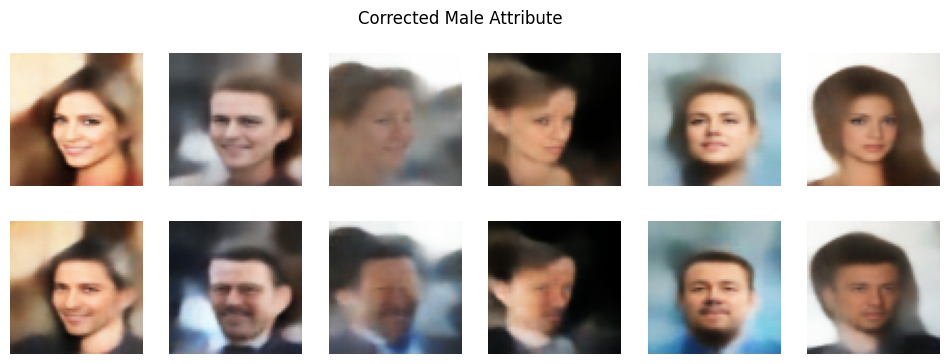

In [31]:
import matplotlib.pyplot as plt

z_base = aligned_latent_vectors[:6]
strength = 2.0

original = vae.decoder(z_base)
modified = vae.decoder(z_base + strength * male_dir_aligned)

plt.figure(figsize=(12, 4))
plt.suptitle("Corrected Male Attribute")

for i in range(6):
    plt.subplot(2, 6, i + 1)
    plt.imshow(original[i])
    plt.axis("off")

    plt.subplot(2, 6, 6 + i + 1)
    plt.imshow(modified[i])
    plt.axis("off")

plt.show()

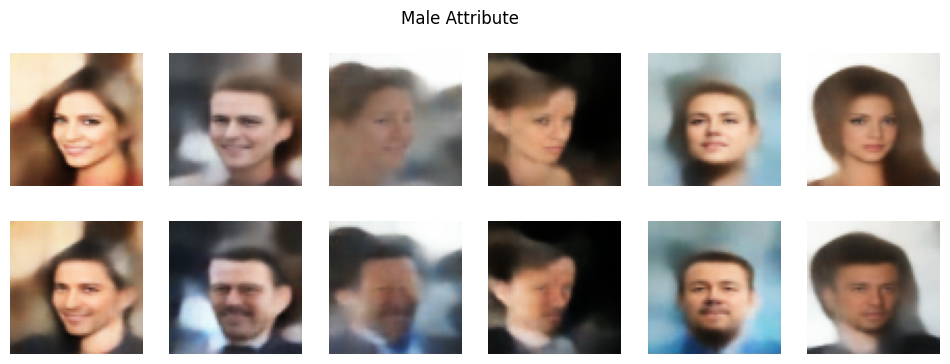

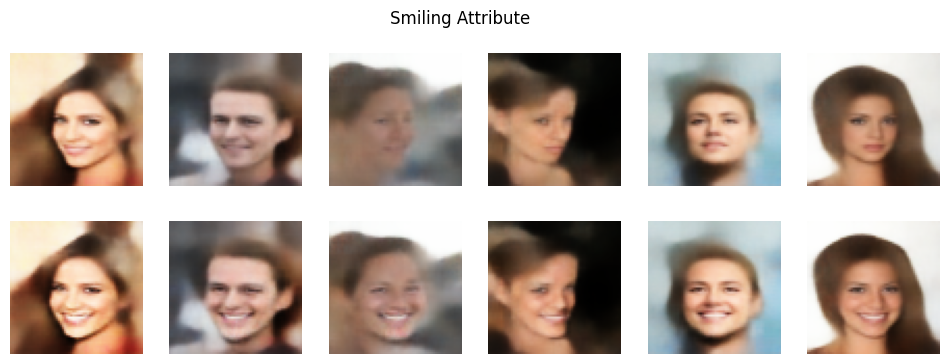

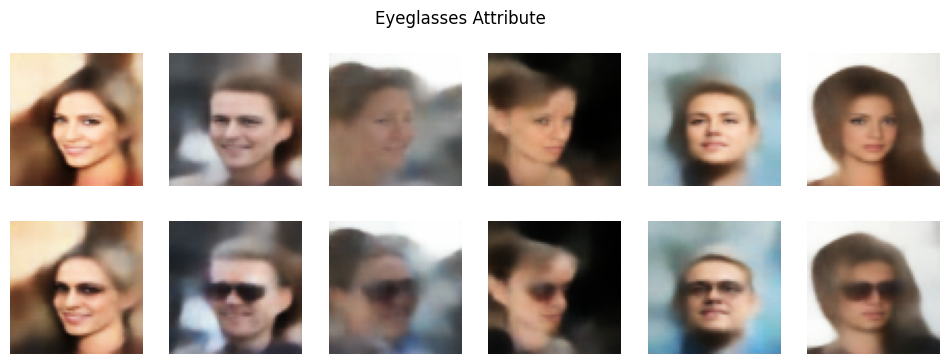

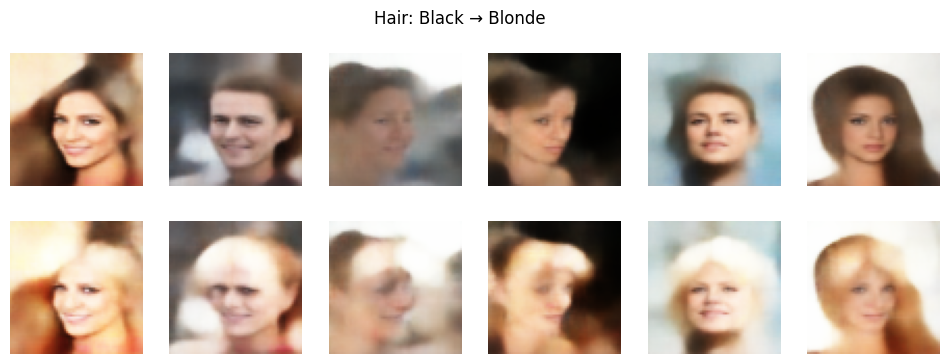

In [33]:
import matplotlib.pyplot as plt

z_base = aligned_latent_vectors[:6]
strength = 2.0

def show_attribute(direction, title):
    original = vae.decoder(z_base)
    modified = vae.decoder(z_base + strength * direction)

    plt.figure(figsize=(12, 4))
    plt.suptitle(title)

    for i in range(6):
        # original
        plt.subplot(2, 6, i + 1)
        plt.imshow(original[i])
        plt.axis("off")

        # modified
        plt.subplot(2, 6, 6 + i + 1)
        plt.imshow(modified[i])
        plt.axis("off")

    plt.show()


show_attribute(male_dir_aligned, "Male Attribute")
show_attribute(smile_dir_aligned, "Smiling Attribute")
show_attribute(glasses_dir_aligned, "Eyeglasses Attribute")
show_attribute(hair_dir_aligned, "Hair: Black → Blonde")